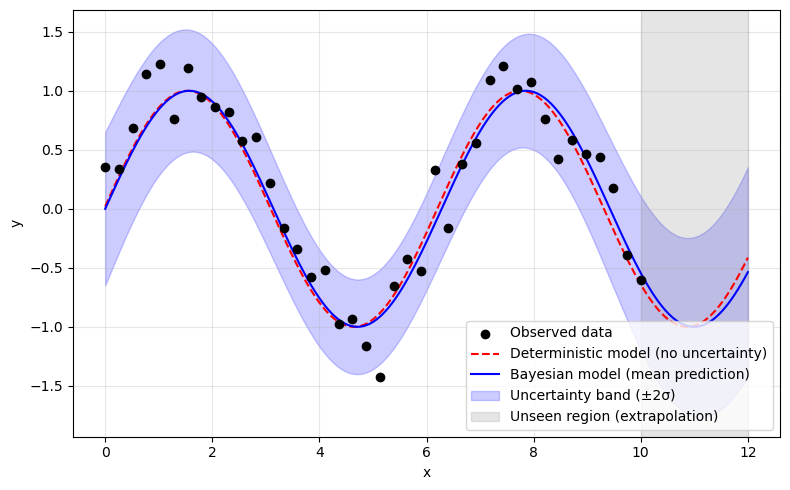

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data: noisy sine wave
np.random.seed(0)
x = np.linspace(0, 10, 40)
y_true = np.sin(x)
noise = np.random.normal(0, 0.2, size=len(x))
y_obs = y_true + noise

# Define predictions for two models:
x_pred = np.linspace(0, 12, 200)

# 1. Deterministic model (e.g. standard neural network)
y_pred_deterministic = np.sin(x_pred*1.01+0.02)  # Perfect mean prediction, no uncertainty

# 2. Bayesian model (e.g. probabilistic neural net)
y_pred_mean = np.sin(x_pred)
uncertainty = 0.2 + 0.05 * (x_pred - 5)**2 / 10  # More uncertainty far from data
y_upper = y_pred_mean + 2 * uncertainty
y_lower = y_pred_mean - 2 * uncertainty

# Plot the results
plt.figure(figsize=(8, 5))
plt.scatter(x, y_obs, color='black', label='Observed data', zorder=3)
plt.plot(x_pred, y_pred_deterministic, 'r--', label='Deterministic model (no uncertainty)')
plt.plot(x_pred, y_pred_mean, 'b-', label='Bayesian model (mean prediction)')
plt.fill_between(x_pred, y_lower, y_upper, color='blue', alpha=0.2, label='Uncertainty band (±2σ)')
plt.axvspan(10, 12, color='gray', alpha=0.2, label='Unseen region (extrapolation)')
plt.xlabel("x")
plt.ylabel("y")
#plt.title("Quantifying Uncertainty in Machine Learning Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ML-unc.pdf")
plt.show()

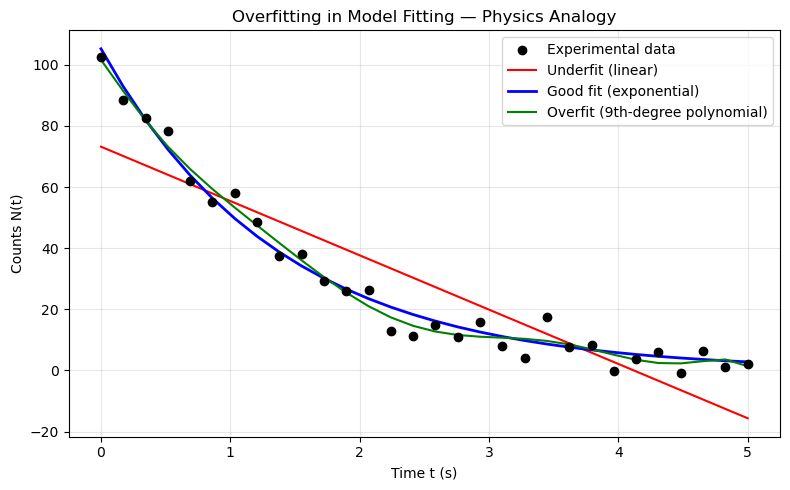

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# 1. Generate synthetic decay data
# -----------------------------
np.random.seed(42)
t = np.linspace(0, 5, 30)                    # time (s)
true_tau = 1.5
N0 = 100
N_true = N0 * np.exp(-t / true_tau)          # true exponential decay law
noise = np.random.normal(0, 5, size=len(t))  # experimental noise
N_data = N_true + noise                      # noisy observations

# -----------------------------
# 2. Fit three different models
# -----------------------------

# (a) Underfit: linear model
coeff_lin = np.polyfit(t, N_data, 1)
N_lin = np.polyval(coeff_lin, t)

# (b) Good fit: exponential model
def exp_model(t, N0, tau):
    return N0 * np.exp(-t / tau)

params, _ = curve_fit(exp_model, t, N_data, p0=(100, 1))
N_exp = exp_model(t, *params)

# (c) Overfit: 9th-degree polynomial
coeff_poly = np.polyfit(t, N_data, 9)
N_poly = np.polyval(coeff_poly, t)

# -----------------------------
# 3. Plot all fits together
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(t, N_data, color='black', label='Experimental data', zorder=3)
#plt.plot(t, N_true, 'k--', label='True law (exponential)', linewidth=2)
plt.plot(t, N_lin, 'r-', label='Underfit (linear)', linewidth=1.5)
plt.plot(t, N_exp, 'b-', label='Good fit (exponential)', linewidth=2)
plt.plot(t, N_poly, 'g-', label='Overfit (9th-degree polynomial)', linewidth=1.5)
plt.xlabel("Time t (s)")
plt.ylabel("Counts N(t)")
plt.title("Overfitting in Model Fitting — Physics Analogy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ML-overfit.pdf")
plt.show()